# Scratch Notebook

**Purpose:** Ad hoc exploration and quick experiments. Not part of the analysis sequence.

This notebook has no structure — it was used for one-off testing during development. Do not rely on it for reproducible results.

In [1]:
import matplotlib.pyplot as plt

Text(0.5, 0, 'Mean Difference in F1-Score')

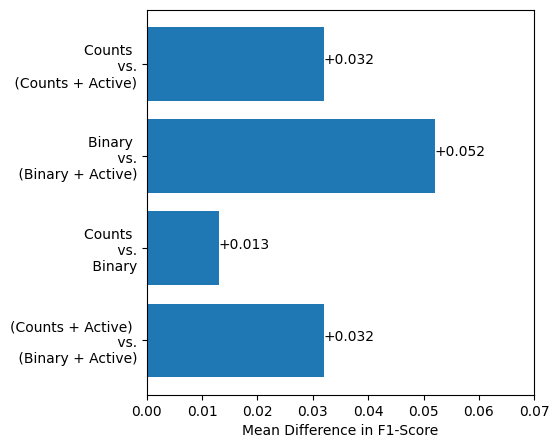

In [2]:
# create a horizontal bar chart
plt.figure(figsize=(5, 5))

labels = ["Counts \n vs.\n (Counts + Active)", "Binary \n vs.\n (Binary + Active)", "Counts \n vs.\n Binary", "(Counts + Active) \n vs.\n (Binary + Active)"]
values = [0.032, 0.052, 0.013, 0.032]

# reverse the order of the labels and values
labels = labels[::-1]
values = values[::-1]

# display bar chart in the order of the labels
plt.barh(labels, values)

# display labels on each bar
for index, value in enumerate(values):
    plt.text(value, index, "+"+str(value))

# shorten the bars to make the labels fit
plt.xlim(0, 0.07)

# add title and labels
plt.xlabel("Mean Difference in F1-Score")

In [3]:
import pickle

data = pickle.load(open('../data/home_data_eval_all_preds.pkl', 'rb'))

In [4]:
data

{'communication-mgmt_SCI06-7--11_frame49': {'ground_truth': {'boxes': array([[ 982,  524, 1258,  960],
          [   0,  158,  747,  671],
          [1437,   53, 1920,  944],
          [ 460,  401,  533,  613]]),
   'classes': [17, 11, 11, 15],
   'classes_og': [153, 135, 135, 6],
   'labels': ['phone_tablet', 'furniture', 'furniture', 'electronics'],
   'active': [True, False, False, False]},
  'unidet_data': {'boxes': array([[ 988,  523, 1252,  969]]),
   'classes': [17],
   'classes_og': [153],
   'labels': ['phone_tablet'],
   'scores': [0.9762368],
   'active': [True]},
  'detic_data': {'boxes': array([[ 988,  523, 1253,  968],
          [ 469,  403,  522,  609],
          [ 971,    3, 1238,  241],
          [1452,   36, 1920, 1054],
          [ 799,  964,  877, 1079],
          [  70,    0,  277,  231],
          [ 367,  448,  433,  509],
          [ 686,   49,  777,   86],
          [ 370,  283,  592,  616],
          [ 279,  132,  384,  243],
          [1616,  998, 1661, 1079],

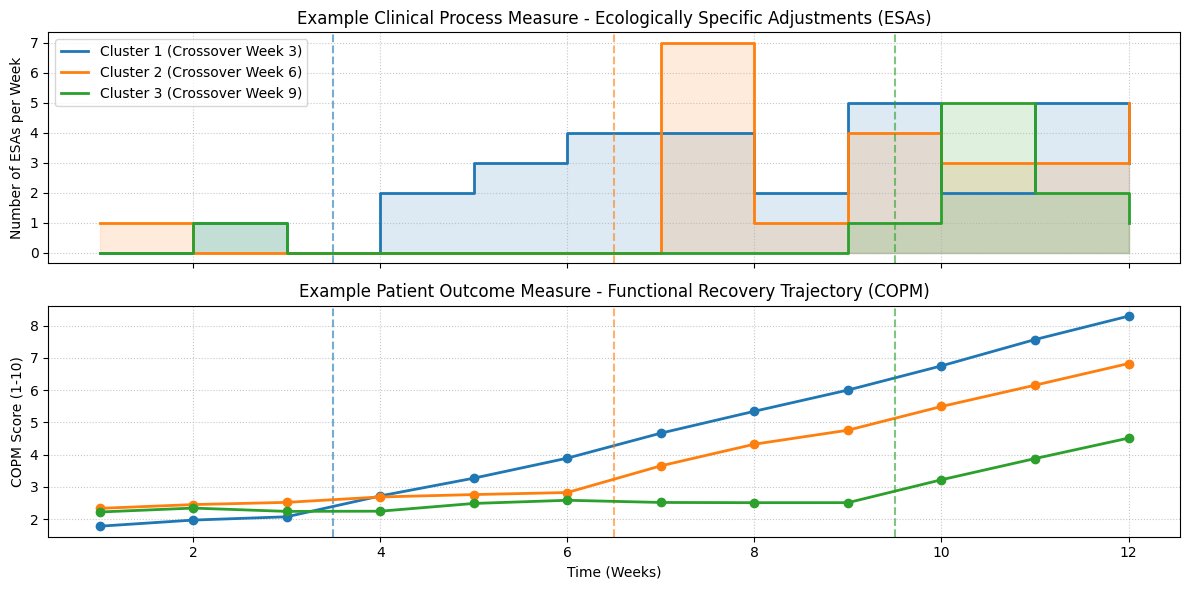

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
weeks = np.arange(1, 13)
clusters = ['Cluster 1', 'Cluster 2', 'Cluster 3']
crossover_weeks = [3, 6, 9]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# 1. Plot for Ecologically Specific Adjustments (ESAs)
for i, (cluster, crossover, color) in enumerate(zip(clusters, crossover_weeks, colors)):
    # Baseline: 0 or 1 with some noise
    baseline = np.random.poisson(0.2, crossover)
    # Intervention: jump to 3-6 with noise
    intervention = np.random.poisson(4.0, len(weeks) - crossover)
    esas = np.concatenate([baseline, intervention])
    
    # Step plot
    ax1.step(weeks, esas, where='post', label=f"{cluster} (Crossover Week {crossover})", color=color, linewidth=2)
    # Add transparent fill
    ax1.fill_between(weeks, esas, step='post', alpha=0.15, color=color)
    # Vertical line for crossover
    ax1.axvline(x=crossover + 0.5, color=color, linestyle='--', alpha=0.6)

ax1.set_ylabel('Number of ESAs per Week')
ax1.set_title('Example Clinical Process Measure - Ecologically Specific Adjustments (ESAs)')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)

# 2. Plot for COPM (Canadian Occupational Performance Measure)
# Scale typically 1-10
for i, (cluster, crossover, color) in enumerate(zip(clusters, crossover_weeks, colors)):
    # Start score around 2.0
    start_score = 2.0 + np.random.normal(0, 0.3)
    # Baseline slope: 0.1 points/week (minor spontaneous recovery)
    baseline_slope = 0.1
    # Intervention slope: 0.7 points/week (accelerated improvement)
    intervention_slope = 0.7
    
    scores = []
    current_score = start_score
    for w in range(len(weeks)):
        if w < crossover:
            current_score += baseline_slope + np.random.normal(0, 0.1)
        else:
            current_score += intervention_slope + np.random.normal(0, 0.1)
        # Clip to max 10
        current_score = min(current_score, 10.0)
        scores.append(current_score)
    
    ax2.plot(weeks, scores, marker='o', label=cluster, color=color, linewidth=2)
    ax2.axvline(x=crossover + 0.5, color=color, linestyle='--', alpha=0.6)

ax2.set_xlabel('Time (Weeks)')
ax2.set_ylabel('COPM Score (1-10)')
ax2.set_title('Example Patient Outcome Measure - Functional Recovery Trajectory (COPM)')
ax2.grid(True, linestyle=':', alpha=0.7)

# Adjust layout and save
plt.tight_layout()
plt.savefig('clinical_trial_visuals_copm.png', dpi=300)